In [2]:
!pip install nibabel scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.6 MB/s eta 0:00:00


In [4]:
! pip install scipy

Lancement du FCM sur la coupe 68...
Calcul termine affichage de image en cours...


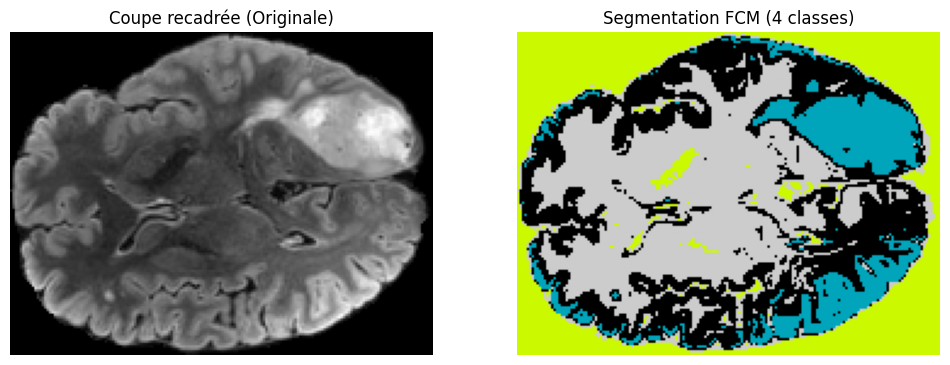

In [6]:
import numpy as np
import nibabel as nib
import skfuzzy as fuzz
import matplotlib.pyplot as plt

#FONCTION DE RECADRAGE (AUTO-CROP) ---
def find_bounding_box(volume_data):
    non_zero_coords = np.argwhere(volume_data > 0)
    if non_zero_coords.size == 0:
        return None, None
    min_coords = non_zero_coords.min(axis=0)
    max_coords = non_zero_coords.max(axis=0) + 1
    return min_coords, max_coords

# CHARGEMENT ET RECADRAGE DE L'IMAGE ---
file_path = '/content/00000209_brain_flair.nii'
img = nib.load(file_path)
data = img.get_fdata()

min_c, max_c = find_bounding_box(data)
cropped_data = data[min_c[0]:max_c[0], min_c[1]:max_c[1], min_c[2]:max_c[2]]

#EXTRACTION D'UNE COUPE 2D ---

z_mid = cropped_data.shape[2] // 2
slice_2d = cropped_data[:, :, z_mid]

shape_2d = slice_2d.shape
data_flat = slice_2d.reshape(1, -1)

# APPLICATION DU FUZZY C-MEANS ---
print(f"Lancement du FCM sur la coupe {z_mid}...")
n_clusters = 4 # On cherche 4 zones (Fond noir, Cerveau sain, Oedeme, Coeur actif)

# u est la matrice des probabilités floues (le fameux degré d'appartenance)
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data_flat, c=n_clusters, m=2, error=0.005, maxiter=100, init=None
)

#RECONSTRUCTION DE L'IMAGE SEGMENTEE ---

segmented_flat = np.argmax(u, axis=0)

segmented_2d = segmented_flat.reshape(shape_2d)

# AFFICHAGE VISUEL ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(slice_2d, cmap='gray')
axes[0].set_title('Coupe recadrée (Originale)')
axes[0].axis('off')

# utilisation de 'nipy_spectral' permet de donner des couleurs  aux clusters
axes[1].imshow(segmented_2d, cmap='nipy_spectral')
axes[1].set_title(f'Segmentation FCM ({n_clusters} classes)')
axes[1].axis('off')

print("Calcul termine affichage de image en cours...")
plt.show()